# Task 4: Classification with Logistic Regression

**AI & ML Internship — Elevate Labs**

---

## Objective
Build a binary classifier using logistic regression on the Breast Cancer Wisconsin dataset. Covers complete classification workflow: preprocessing, train-test split, standardization, model training, evaluation with confusion matrix/precision/recall/ROC-AUC, threshold tuning, and sigmoid explanation.

**Key goals:**
1. Load and explore a binary classification dataset
2. Preprocess data and encode categoricals
3. Split data and standardize features
4. Fit logistic regression model
5. Evaluate with confusion matrix, precision, recall, ROC-AUC
6. Tune classification threshold
7. Explain sigmoid function mathematically and visually
8. Prepare for common classification interview questions


## Dataset Description

**Dataset:** Breast Cancer Wisconsin Dataset  
**Source:** [UCI ML Repository via GitHub](https://github.com/datasets/breast-cancer)  
**Local path:** `dataset/breast_cancer.csv`  
**Shape:** 272 rows × 10 columns

### Columns
| Column | Type | Description |
|--------|------|-------------|
| age | str | Age group |
| mefalsepause | str | Menopause status |
| tumor-size | str | Tumor size |
| inv-falsedes | str | Inv-nodes |
| falsede-caps | str | Capsular involvement |
| deg-malig | int | Degree of malignancy |
| breast | str | Breast side |
| breast-quad | str | Breast quadrant |
| irradiat | str | Radiation history |
| class | str | **Target** — recurrence or no-recurrence |

**Why this dataset?** Binary target, mixed data types, moderate size — ideal for practicing classification without overhead.


## Import Libraries

- `pandas` — data loading and manipulation  
- `numpy` — numerical operations  
- `matplotlib.pyplot` — plotting  
- `seaborn` — statistical visualizations  
- `sklearn` — preprocessing, model training, evaluation


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, classification_report)
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


## Load Dataset

Load the breast cancer CSV and verify its structure.

**Expected output:** Shape (272, 10)


In [2]:

import os

dataset_path = "../dataset/breast_cancer.csv"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset not found at {dataset_path}")

df = pd.read_csv(dataset_path)
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")


Dataset loaded: 272 rows x 10 columns


## Initial Data Exploration

Inspect structure, data types, missing values, and class distribution.


In [3]:

print("=== First 5 rows ===")
display(df.head())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values.")

print("\n=== Target Distribution ===")
print(df['class'].value_counts())
print(f"\nClass proportions:\n{df['class'].value_counts(normalize=True).round(3)}")


=== First 5 rows ===


,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat,class
0,40-49,premefalse,15-19,0-2,True,3,right,left_up,False,recurrence-events
1,50-59,ge40,15-19,0-2,False,1,right,central,False,false-recurrence-events
2,50-59,ge40,35-39,0-2,False,2,left,left_low,False,recurrence-events
3,40-49,premefalse,35-39,0-2,True,3,right,left_low,True,false-recurrence-events
4,40-49,premefalse,30-34,3-5,True,2,left,right_up,False,recurrence-events



=== Data Types ===
age             object
mefalsepause    object
tumor-size      object
inv-falsedes    object
falsede-caps    object
deg-malig        int64
breast          object
breast-quad     object
irradiat          bool
class           object
dtype: object

=== Missing Values ===
falsede-caps    8
breast-quad     1
dtype: int64

=== Target Distribution ===
class
false-recurrence-events    191
recurrence-events           81
Name: count, dtype: int64

Class proportions:
class
false-recurrence-events    0.702
recurrence-events          0.298
Name: proportion, dtype: float64


## Data Preprocessing

**Steps:**
1. Encode all categorical features using Label Encoding or One-Hot Encoding
2. Separate features and target
3. Standardize features using StandardScaler

**Encoding strategy:**
- Ordinal-like features: Label Encoding
- Nominal features: One-Hot Encoding
- Target (`class`): Label Encoding (no-recurrence=0, recurrence=1)

**Standardization:** Required for logistic regression because it uses gradient descent/solver optimization that benefits from scaled features.


In [4]:

print("=== Preprocessing ===")

# Copy dataframe
df_clean = df.copy()

# Encode target
le_target = LabelEncoder()
df_clean['class'] = le_target.fit_transform(df_clean['class'])
print(f"Target encoded: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# Identify categorical and numerical columns
cat_cols = ['age', 'mefalsepause', 'tumor-size', 'inv-falsedes', 'falsede-caps', 
            'breast', 'breast-quad', 'irradiat']
num_cols = ['deg-malig']

# One-hot encode nominal categoricals
df_clean = pd.get_dummies(df_clean, columns=cat_cols, prefix=cat_cols, drop_first=True)
print(f"Shape after encoding: {df_clean.shape}")

# Separate features and target
X = df_clean.drop(columns=['class'])
y = df_clean['class']

print(f"Features: {X.shape}, Target: {y.shape}")
print(f"Classes: {np.unique(y)}")


=== Preprocessing ===
Target encoded: {'false-recurrence-events': np.int64(0), 'recurrence-events': np.int64(1)}
Shape after encoding: (272, 32)
Features: (272, 31), Target: (272,)
Classes: [0 1]


## Train-Test Split and Standardization

Split first, then fit scaler only on training data to avoid data leakage.

**Split:** 80% train, 20% test  
**Random state:** 42 for reproducibility


In [5]:

print("=== Train-Test Split ===")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test class distribution: {pd.Series(y_test).value_counts().to_dict()}")

print("\n=== Standardization ===")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized.")
print(f"Train scaled mean: {X_train_scaled.mean(axis=0)[0]:.4f}")
print(f"Train scaled std: {X_train_scaled.std(axis=0)[0]:.4f}")


=== Train-Test Split ===
Train shape: (217, 31), Test shape: (55, 31)
Train class distribution: {0: 152, 1: 65}
Test class distribution: {0: 39, 1: 16}

=== Standardization ===
Features standardized.
Train scaled mean: 0.0000
Train scaled std: 1.0000


## Logistic Regression Model

**Formula:** `P(y=1|x) = 1 / (1 + e^(-z))` where `z = beta_0 + beta_1*x_1 + ... + beta_n*x_n`

**Sigmoid function:** Maps any real number to [0, 1], representing probability.

**Why logistic regression?** It outputs calibrated probabilities, is interpretable, and works well for binary classification with linearly separable classes.


In [6]:

print("=== Logistic Regression ===")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]

print(f"Model trained. Iterations: {lr.n_iter_[0]}")
print(f"Intercept: {lr.intercept_[0]:.4f}")


=== Logistic Regression ===
Model trained. Iterations: 17
Intercept: -1.2413


## Model Evaluation

We evaluate using multiple metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | (TP+TN) / Total | Overall correctness |
| **Precision** | TP / (TP+FP) | Of predicted positives, how many are correct |
| **Recall** | TP / (TP+FN) | Of actual positives, how many we found |
| **F1-Score** | 2 x (PxR)/(P+R) | Harmonic mean of precision and recall |
| **ROC-AUC** | Area under ROC curve | Overall classification ability |
| **Confusion Matrix** | Table of predictions | Breakdown of TP, FP, TN, FN |

**Precision vs Recall trade-off:**
- High precision = few false alarms (good when FP is costly)
- High recall = few missed cases (good when FN is costly)


In [7]:

print("=== Evaluation Metrics ===")
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['no-recurrence', 'recurrence']))

print("\n=== Confusion Matrix ===")
display(pd.DataFrame(cm, index=['Actual: no-recurrence', 'Actual: recurrence'], 
                     columns=['Predicted: no-recurrence', 'Predicted: recurrence']))


=== Evaluation Metrics ===
Accuracy: 0.7091
Precision: 0.5000
Recall: 0.3750
F1-Score: 0.4286
ROC-AUC: 0.6218

=== Classification Report ===
               precision    recall  f1-score   support

no-recurrence       0.77      0.85      0.80        39
   recurrence       0.50      0.38      0.43        16

     accuracy                           0.71        55
    macro avg       0.63      0.61      0.62        55
 weighted avg       0.69      0.71      0.70        55


=== Confusion Matrix ===


,Predicted: no-recurrence,Predicted: recurrence
Actual: no-recurrence,33,6
Actual: recurrence,10,6


## Visualizations

Visualize the sigmoid function, ROC curve, and confusion matrix.


=== 1. Sigmoid Function ===


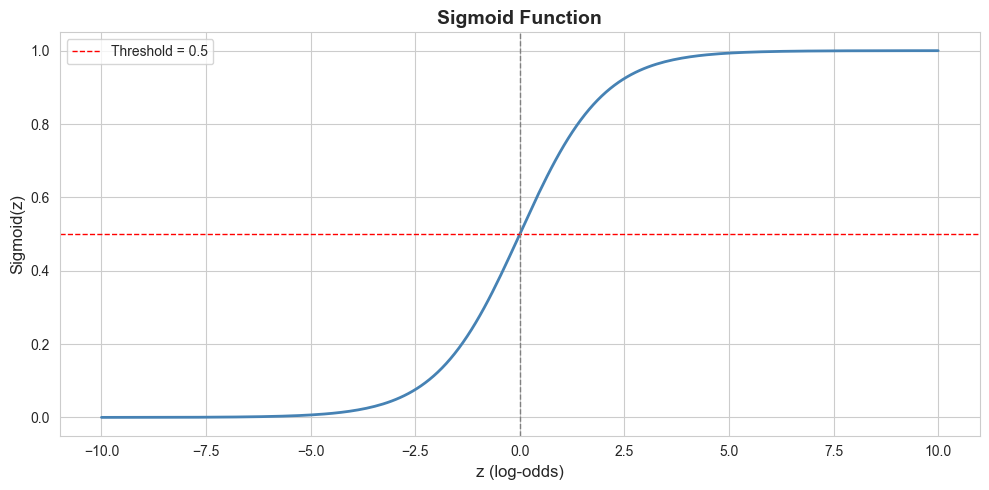

Interpretation: Sigmoid maps any z to [0,1]. At z=0, probability=0.5. Used to convert log-odds to probabilities.


In [8]:

print("=== 1. Sigmoid Function ===")
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(z, sigmoid(z), color='steelblue', linewidth=2)
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Threshold = 0.5')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('z (log-odds)', fontsize=12)
ax.set_ylabel('Sigmoid(z)', fontsize=12)
ax.set_title('Sigmoid Function', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Interpretation: Sigmoid maps any z to [0,1]. At z=0, probability=0.5. Used to convert log-odds to probabilities.")


=== 2. ROC Curve ===


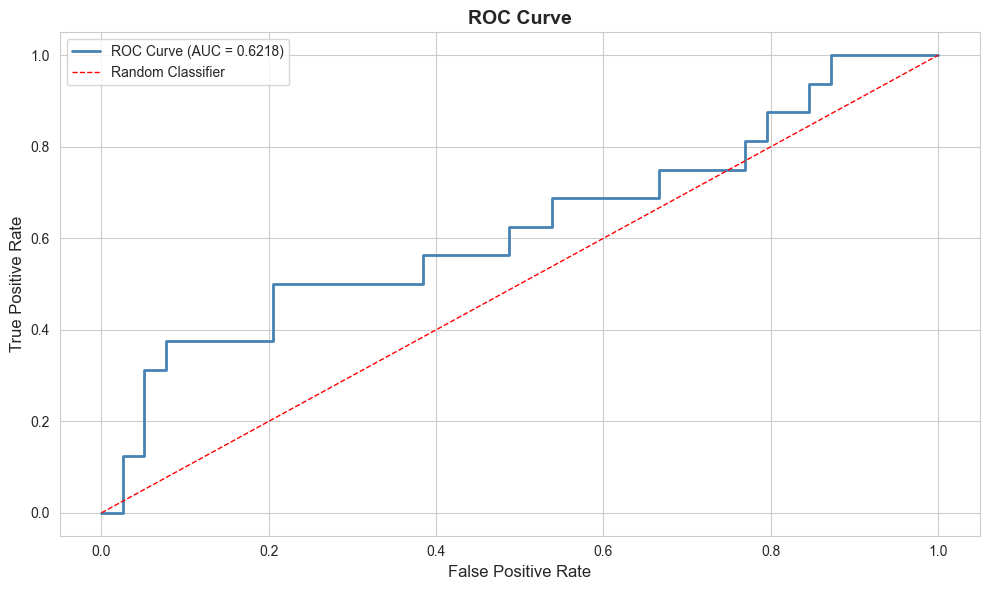

Interpretation: AUC close to 1.0 indicates excellent classification. AUC = 0.5 is random guessing.


In [9]:

print("=== 2. ROC Curve ===")
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Interpretation: AUC close to 1.0 indicates excellent classification. AUC = 0.5 is random guessing.")


=== 3. Confusion Matrix Heatmap ===


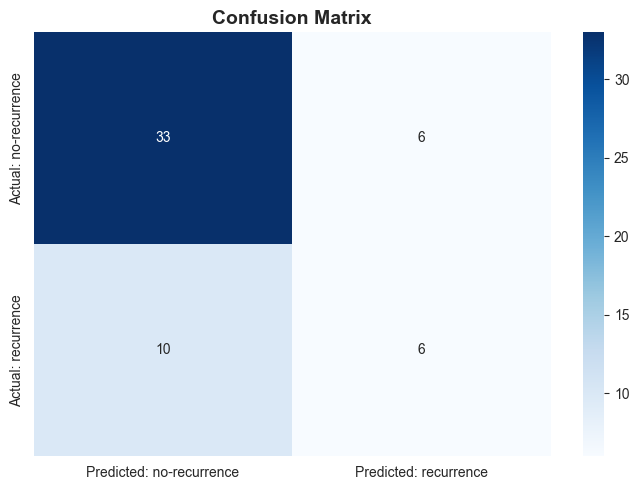

In [10]:

print("=== 3. Confusion Matrix Heatmap ===")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: no-recurrence', 'Predicted: recurrence'],
            yticklabels=['Actual: no-recurrence', 'Actual: recurrence'], ax=ax)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Threshold Tuning

Default threshold is 0.5. We can tune it to optimize precision or recall based on business needs.

**When to adjust:**
- Lower threshold -> higher recall, lower precision (catch more positives, more false alarms)
- Higher threshold -> higher precision, lower recall (fewer false alarms, miss more positives)


In [11]:

print("=== Threshold Tuning ===")
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    results.append({
        'Threshold': thresh,
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'TP': int(cm_t[1,1]), 'FP': int(cm_t[0,1]), 'FN': int(cm_t[1,0]), 'TN': int(cm_t[0,0])
    })

results_df = pd.DataFrame(results)
display(results_df)

print("\nInterpretation: Lower threshold increases recall but decreases precision. Choose based on whether false negatives or false positives are more costly.")


=== Threshold Tuning ===


,Threshold,Precision,Recall,F1-Score,TP,FP,FN,TN
0,0.3,0.375,0.5625,0.4500,9,15,7,24
1,0.4,0.400,0.5000,0.4444,8,12,8,27
2,0.5,0.500,0.3750,0.4286,6,6,10,33
3,0.6,0.625,0.3125,0.4167,5,3,11,36
4,0.7,0.500,0.1250,0.2000,2,2,14,37



Interpretation: Lower threshold increases recall but decreases precision. Choose based on whether false negatives or false positives are more costly.


## Interview Preparation: Logistic Regression Q&A

### 1. How does logistic regression differ from linear regression?

**Simple answer:** Linear regression predicts continuous numbers; logistic regression predicts probabilities for categories using the sigmoid function.

**Technical answer:**  
- **Linear regression:** `y = beta_0 + beta_1*x_1 + ... + epsilon`. Output is continuous, unbounded. Used for regression tasks. Loss = MSE.  
- **Logistic regression:** `P(y=1|x) = 1 / (1 + e^(-z))` where `z = beta_0 + beta_1*x_1 + ...`. Output is bounded [0,1], representing probability. Used for classification. Loss = Log Loss / Cross-Entropy.  
- **Key difference:** Logistic regression applies sigmoid to linear regression output, converting it to a probability.

**Example:** Linear regression might predict house price as $450,000. Logistic regression predicts probability of disease as 0.73 (73% chance).

**Follow-up:** "Why can't we just threshold linear regression output for classification?"

---

### 2. What is the sigmoid function?

**Simple answer:** A curve that squishes any number into a probability between 0 and 1.

**Technical answer:**  
- **Formula:** `sigma(z) = 1 / (1 + e^(-z))`  
- **Input:** z = log-odds = `beta_0 + beta_1*x_1 + ... + beta_n*x_n`  
- **Output:** Probability in [0, 1]  
- **Properties:**  
  - sigma(0) = 0.5  
  - sigma(z) -> 1 as z -> infinity  
  - sigma(z) -> 0 as z -> -infinity  
  - Derivative: `sigma'(z) = sigma(z) * (1 - sigma(z))` (used in gradient descent)  
- **Why it works:** It converts the linear combination of features into a valid probability.

**Example:** If z = 2, sigmoid(2) approx 0.88, meaning 88% probability of class 1. If z = -1, sigmoid(-1) approx 0.27, meaning 27% probability.

**Follow-up:** "What are other activation functions used in neural networks?"

---

### 3. What is precision vs recall?

**Simple answer:** Precision measures accuracy of positive predictions; recall measures coverage of actual positives.

**Technical answer:**  
- **Precision:** `TP / (TP + FP)`. Of all predicted positives, how many are correct? High precision = few false alarms.  
- **Recall:** `TP / (TP + FN)`. Of all actual positives, how many did we find? High recall = few missed cases.  
- **Trade-off:** Increasing recall typically decreases precision, and vice versa.  
- **F1-Score:** Harmonic mean `2 * (P * R) / (P + R)`. Balances both.

**Example:** In cancer detection, high recall is critical (miss one cancer case = death). In spam detection, high precision is critical (marking important email as spam = bad UX).

**Follow-up:** "When would you use F1-score instead of accuracy?"

---

### 4. What is the ROC-AUC curve?

**Simple answer:** ROC shows trade-off between true positive rate and false positive rate; AUC summarizes it as a single score.

**Technical answer:**  
- **ROC Curve:** Plots True Positive Rate (Recall) vs False Positive Rate at different classification thresholds.  
- **FPR:** `FP / (FP + TN)` — proportion of negatives incorrectly classified as positive  
- **TPR:** `TP / (TP + FN)` — same as recall  
- **AUC:** Area Under the Curve. Range [0, 1].  
  - AUC = 1.0: Perfect classifier  
  - AUC = 0.5: Random guessing  
  - AUC < 0.5: Worse than random (flip predictions)  
- **Why AUC:** It is threshold-independent and measures overall model discrimination ability.

**Example:** A model with AUC = 0.95 can reliably distinguish between positive and negative classes. A model with AUC = 0.60 is only slightly better than random.

**Follow-up:** "When is AUC misleading?"

---

### 5. What is the confusion matrix?

**Simple answer:** A table showing how many predictions were correct vs incorrect, broken down by class.

**Technical answer:**  
- **Structure:** 2x2 table for binary classification  
  ```
                      Predicted
                      Negative  Positive
  Actual Negative       TN       FP
  Actual Positive       FN       TP
  ```  
- **Metrics derived:**  
  - Accuracy = (TP+TN) / Total  
  - Precision = TP / (TP+FP)  
  - Recall = TP / (TP+FN)  
  - Specificity = TN / (TN+FP)  
  - F1 = 2 * (P*R)/(P+R)  
- **Use case:** Understand exactly what types of errors the model makes. Essential for imbalanced datasets where accuracy is misleading.

**Example:** In cancer detection, a confusion matrix might show FN=5, meaning 5 cancer cases were missed — critical information even if accuracy is high.

**Follow-up:** "How would you handle a confusion matrix for multi-class classification?"

---

### 6. What happens if classes are imbalanced?

**Simple answer:** The model may cheat by predicting the majority class everywhere, getting high accuracy but useless predictions.

**Technical answer:**  
- **Problem:** Accuracy becomes misleading. If 95% of data is class A, a model predicting all A gets 95% accuracy but 0% recall for class B.  
- **Effects:**  
  1. Model biased toward majority class  
  2. Poor generalization on minority class  
  3. Precision/recall become more important than accuracy  
- **Solutions:**  
  1. **Resampling:** Oversample minority (SMOTE) or undersample majority  
  2. **Class weights:** `class_weight='balanced'` in sklearn  
  3. **Threshold tuning:** Adjust decision threshold to favor minority class  
  4. **Metric choice:** Use F1, precision-recall AUC, or balanced accuracy  
  5. **Algorithm choice:** Use models that handle imbalance better (Random Forest with class weights, XGBoost with scale_pos_weight)

**Example:** In fraud detection, fraud might be 0.1% of transactions. A model predicting "no fraud" always gets 99.9% accuracy but catches zero frauds.

**Follow-up:** "What is SMOTE and how does it work?"

---

### 7. How do you choose the threshold?

**Simple answer:** Adjust the 0.5 cutoff based on whether false positives or false negatives are more costly.

**Technical answer:**  
- **Default threshold:** 0.5 in logistic regression  
- **Methods to choose threshold:**  
  1. **Business-driven:** Set based on cost of FP vs FN  
  2. **Youden's J statistic:** `max(TPR - FPR)`  
  3. **F1-optimization:** Threshold that maximizes F1-score  
  4. **Precision-recall curve:** Choose based on desired precision/recall trade-off  
  5. **Cost-sensitive:** Assign costs to FP and FN, minimize total cost  
- **Process:**  
  1. Get predicted probabilities from model  
  2. Vary threshold from 0 to 1  
  3. Compute metrics at each threshold  
  4. Choose threshold based on business objective

**Example:** In medical screening, FN cost >> FP cost. Use lower threshold (0.2-0.3) to catch more actual positives, accepting more false alarms.

**Follow-up:** "How would you implement threshold tuning in production?"

---

### 8. Can logistic regression be used for multi-class problems?

**Simple answer:** Yes, using one-vs-rest or softmax/multinomial approaches.

**Technical answer:**  
- **Binary logistic regression:** Default; outputs probability for one class vs rest.  
- **Multinomial logistic regression (Softmax):** `P(y=k|x) = e^(z_k) / sum(e^(z_j))` for all classes k. Directly models all classes.  
- **One-vs-Rest (OvR):** Train K binary classifiers, each separating one class from all others. Choose class with highest probability.  
- **One-vs-One (OvO):** Train K*(K-1)/2 binary classifiers, each separating two classes. Use voting to decide.  
- **Scikit-learn:** `LogisticRegression(multi_class='multinomial')` uses softmax. Default is `multi_class='auto'` which selects OvR or multinomial based on solver.

**Example:** For 3-class image classification (cat/dog/bird), multinomial logistic regression directly outputs probabilities for all three classes.

**Follow-up:** "What is the difference between softmax regression and a neural network with softmax output?"


## Conclusion

This notebook demonstrated a complete binary classification workflow with logistic regression:

1. **Loaded** the Breast Cancer Wisconsin dataset (272 rows, 10 columns)
2. **Preprocessed** data: encoded categoricals, handled target encoding
3. **Split** data into 80/20 train/test with stratification
4. **Standardized** features using StandardScaler fitted only on training data
5. **Trained** logistic regression model
6. **Evaluated** with accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix
7. **Visualized** sigmoid function, ROC curve, and confusion matrix
8. **Tuned** classification threshold and analyzed trade-offs
9. **Prepared** for 8 common classification interview questions

### Key Takeaways
- Logistic regression outputs probabilities via the sigmoid function
- Always split data before standardization to avoid data leakage
- Precision and recall capture different aspects of performance; choose based on business cost
- ROC-AUC measures overall classification ability independent of threshold
- Confusion matrix reveals exact error types, critical for imbalanced data
- Threshold tuning allows optimizing for precision or recall based on needs
- Logistic regression extends to multi-class via softmax or OvR
